## Part 1: Classification 

### 1.1 Recent researches

To classify the different types of El Nino, here we simply refer to some recent works focusing on the CP El Nino. The following picture is cited from Omid Alizadeh et al. [2022], where they summarized the different criteria for CP El Nino and classified ENSO-like events before 2020 into EP, CP and Mix. 

![classification](classification.png)

### 1.2 CP-El Nino indices

To identify CP-El Nino events precisely, we further choose a ENSO indice. Most widely-used ENSO indices are summarised in the following table (Li, Xiaofan et al. [2023]).

<img src="indices.png" width="1000">

Among these indices, we choose WP (CT) ENSO indices introduced by Ren and Jin because both indices can be easily calculated based on Nino3 and Nino4, which are available online https://psl.noaa.gov/data/timeseries/month/. The definations are


\begin{equation}
\left\{
\begin{aligned}
N_{WP} &= N_4-\alpha N_3\\
N_{CT} &= N_3-\alpha N_4
\end{aligned},
\right.
\end{equation}

where 

\begin{equation}
\alpha = 
\left\{
\begin{aligned}
&0.4 ,\ \mathrm{if} \ N_3N_4>0,\\
&0, \ \mathrm{otherwise}.
\end{aligned}
\right.
\end{equation}

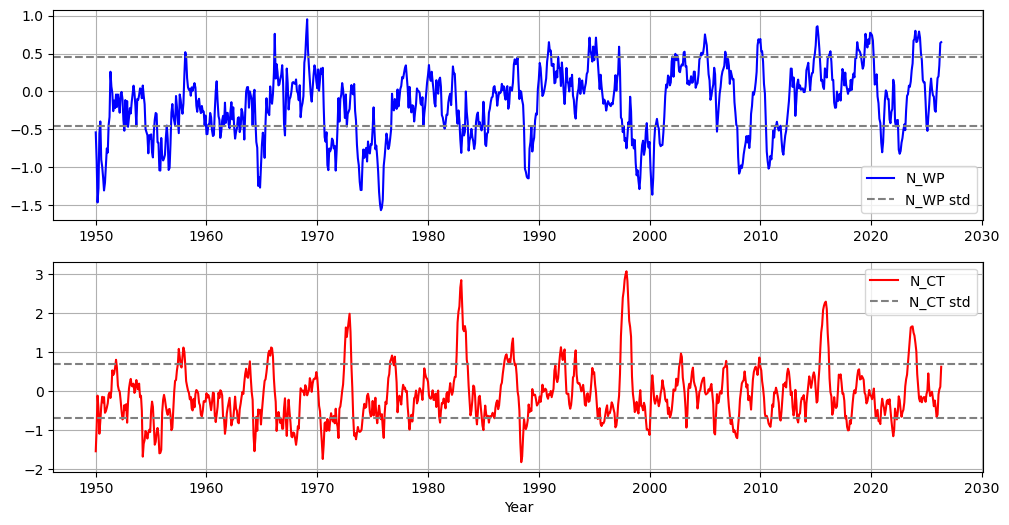

In [243]:
# Calculate N_WP and N_CT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


nino3_file = r"D:\desktop_file\cp_enso\data\nina3.anom.csv"
nino4_file = r"D:\desktop_file\cp_enso\data\nina4.anom.csv"

nino3_df = pd.read_csv(nino3_file, index_col=0, parse_dates=True)
nino4_df = pd.read_csv(nino4_file, index_col=0, parse_dates=True)

time = nino3_df.index
nino3 = nino3_df.values
nino4 = nino4_df.values

# nan
nino3 = np.where(np.abs(nino3) > 100, np.nan, nino3)
nino4 = np.where(np.abs(nino4) > 100, np.nan, nino4)

alpha = np.where(nino3 * nino4 > 0, 0.4, 0)
n_wp = nino4 - alpha * nino3
n_ct = nino3 - alpha * nino4

# calculate the standard deviation of N_WP and N_CT
n_wp_std = np.nanstd(n_wp)
n_ct_std = np.nanstd(n_ct)

# plot time series of N_WP and N_CT separately
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(time, n_wp, label="N_WP", color="blue")

# add the lines for the standard deviation
plt.axhline(n_wp_std, color="grey", linestyle="--", label="N_WP std")
plt.axhline(-n_wp_std, color="grey", linestyle="--")    
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time, n_ct, label="N_CT", color="red")
plt.axhline(n_ct_std, color="grey", linestyle="--", label="N_CT std")
plt.axhline(-n_ct_std, color="grey", linestyle="--")
plt.xlabel("Year")
plt.legend()
plt.grid()
plt.show()


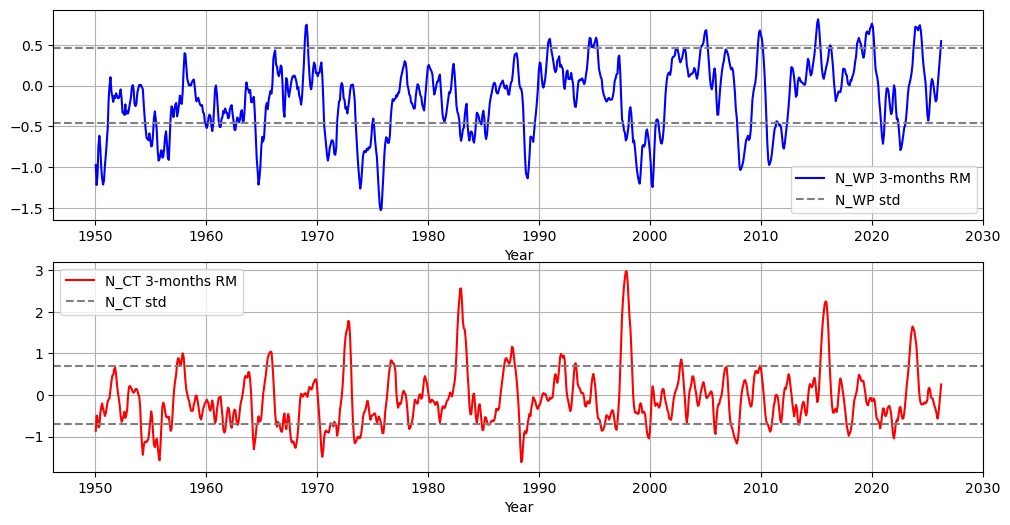

In [ ]:
# calculate the WP El Niño indice based on 3-months running mean of N_WP
n_wp_rm = pd.Series(n_wp.flatten(), index=time).rolling(window=3, center=True).mean().values
n_ct_rm = pd.Series(n_ct.flatten(), index=time).rolling(window=3, center=True).mean().values

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, n_wp_rm, label="N_WP 3-months RM", color="blue")
plt.axhline(n_wp_std, color="grey", linestyle="--", label="N_WP std")
plt.axhline(-n_wp_std, color="grey", linestyle="--")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time, n_ct_rm, label="N_CT 3-months RM", color="red")
plt.axhline(n_ct_std, color="grey", linestyle="--", label="N_CT std")
plt.axhline(-n_ct_std, color="grey", linestyle="--")
plt.xlabel("Year")
plt.legend()
plt.grid()

In [245]:
# find the WP El Niño events 
# Metric: WP indice > N_WP std and last for at least n consecutive months
n = 5

wp_events = []
count = 0
for i in range(len(n_wp_rm)):
    if n_wp_rm[i] > n_wp_std:
        count += 1
    else:
        if count >= n:
            wp_events.append((time[i - count], time[i - 1]))
        count = 0

print("WP El Niño events:")
for start, end in wp_events:
    print(f"{start.strftime('%Y-%m')} to {end.strftime('%Y-%m')}")

WP El Niño events:
1994-07 to 1995-04
2004-08 to 2005-03
2009-10 to 2010-03
2014-12 to 2015-05
2018-09 to 2019-02
2019-06 to 2020-03
2023-11 to 2024-07


In [246]:
# find the CT El Niño events
# Metric: CT indice > N_CT std and last for at least n consecutive months

ct_events = []
count = 0
for i in range(len(n_ct_rm)):
    if n_ct_rm[i] > n_ct_std:
        count += 1
    else:
        if count >= n:
            ct_events.append((time[i - count], time[i - 1]))
        count = 0

print("CT El Niño events:")
for start, end in ct_events:
    print(f"{start.strftime('%Y-%m')} to {end.strftime('%Y-%m')}")

CT El Niño events:
1957-06 to 1958-01
1965-07 to 1966-01
1972-07 to 1973-02
1982-08 to 1983-07
1986-12 to 1987-11
1991-12 to 1992-05
1997-06 to 1998-05
2015-06 to 2016-03
2023-05 to 2024-02


In summary, the EP-El Nino events in this study are `04/05`, `09/10`, `14/15`, `18/19` and `19/20` for the following reasons:

(1) only consider the events after 2000;

(2) the signal of CT El Nino in 23/24 is much stronger than WP El Nino.

## Part 2: Data Downloading

The monthly-mean data are downloaded from https://www.cpc.ncep.noaa.gov/products/GODAS/, where the format is GRIB. The long-term mean data are downloaded from https://www.psl.noaa.gov//data/gridded/data.godas.html, where the format is NetCDF. 

In [247]:
import os
import urllib.request

save_dir = r"D:\desktop_file\cp_enso\data"
os.makedirs(save_dir, exist_ok=True)

base_url = "https://ftp.cpc.ncep.noaa.gov/godas/monthly"

# CP events
cp_enso = [2009, 2010, 2023, 2024]

# download or not
whether_download = False

if whether_download:
    for year in cp_enso:
        for month in range(1, 13):

            yyyymm = f"{year}{month:02d}"

            for suffix in [".grb", ".grb.inv"]:

                filename = f"godas.M.{yyyymm}{suffix}"
                url = f"{base_url}/{filename}"

                save_path = os.path.join(save_dir, filename)

                if os.path.exists(save_path):
                    print(f"Skip: {filename}")
                    continue

                try:
                    urllib.request.urlretrieve(url, save_path)
                    print(f"OK: {filename}")
                except Exception as e:
                    print(f"FAILED: {filename}")
                    print(e)

## Part 3: Data Loading

In [248]:
# import necessary libraries
import xarray as xr
import pygrib
from collections import defaultdict

print(pygrib.__version__)

2.1.6


### 3.1 GRIB

In [249]:
records = []

inv_file = r"data\godas.M.201707.grb.inv"

with open(inv_file) as f:

    for line in f:

        parts = line.strip().split(":")

        records.append({
            "msg": int(parts[0]),
            "offset": int(parts[1]),
            "date": parts[2],
            "var": parts[3],
            "level": parts[4]
        })

df = pd.DataFrame(records)

print(df.head())

   msg  offset        date  var                 level
0    1       0  d=17073100  POT   5 m below sea level
1    2  229156  d=17073100  POT  15 m below sea level
2    3  458312  d=17073100  POT  25 m below sea level
3    4  687468  d=17073100  POT  35 m below sea level
4    5  916624  d=17073100  POT  45 m below sea level


In [250]:
example_file = r"data\godas.M.201707.grb"

grbs = pygrib.open(example_file)

for idx, g in enumerate(grbs, start=1):

    inv_name = df.loc[df.msg == idx, "var"].iloc[0]

    print(
        idx,
        inv_name,
        g.shortName,
        g.level
    )

1 POT pt 5
2 POT pt 15
3 POT pt 25
4 POT pt 35
5 POT pt 45
6 POT pt 55
7 POT pt 65
8 POT pt 75
9 POT pt 85
10 POT pt 95
11 POT pt 105
12 POT pt 115
13 POT pt 125
14 POT pt 135
15 POT pt 145
16 POT pt 155
17 POT pt 165
18 POT pt 175
19 POT pt 185
20 POT pt 195
21 POT pt 205
22 POT pt 215
23 POT pt 225
24 POT pt 238
25 POT pt 262
26 POT pt 303
27 POT pt 366
28 POT pt 459
29 POT pt 584
30 POT pt 747
31 POT pt 949
32 POT pt 1193
33 POT pt 1479
34 POT pt 1807
35 POT pt 2174
36 POT pt 2579
37 POT pt 3016
38 POT pt 3483
39 POT pt 3972
40 POT pt 4478
41 SALTY s 5
42 SALTY s 15
43 SALTY s 25
44 SALTY s 35
45 SALTY s 45
46 SALTY s 55
47 SALTY s 65
48 SALTY s 75
49 SALTY s 85
50 SALTY s 95
51 SALTY s 105
52 SALTY s 115
53 SALTY s 125
54 SALTY s 135
55 SALTY s 145
56 SALTY s 155
57 SALTY s 165
58 SALTY s 175
59 SALTY s 185
60 SALTY s 195
61 SALTY s 205
62 SALTY s 215
63 SALTY s 225
64 SALTY s 238
65 SALTY s 262
66 SALTY s 303
67 SALTY s 366
68 SALTY s 459
69 SALTY s 584
70 SALTY s 747
71 SALTY s 9

In [251]:
grbs = pygrib.open(example_file)

info = defaultdict(list)

for g in grbs:

    data = g.values

    info[g.shortName].append(
        {
            "level": g.level,
            "shape": data.shape,
            "name": g.name
        }
    )

for var, msgs in info.items():
    print("="*50)
    print("Variable:", var)
    print("Description:", msgs[0]["name"])
    print("Levels:", len(msgs))
    print("Horizontal shape:", msgs[0]["shape"])

Variable: pt
Description: Potential temperature
Levels: 40
Horizontal shape: (418, 360)
Variable: s
Description: Salinity
Levels: 40
Horizontal shape: (418, 360)
Variable: ucurr
Description: U-component of current
Levels: 40
Horizontal shape: (418, 360)
Variable: vcurr
Description: V-component of current
Levels: 40
Horizontal shape: (418, 360)
Variable: unknown
Description: unknown
Levels: 40
Horizontal shape: (418, 360)
Variable: lgwsgrd
Description: Longitudinal component of gravity wave stress gradient
Levels: 2
Horizontal shape: (418, 360)
Variable: srcgrd
Description: Skin reservoir content gradient
Levels: 1
Horizontal shape: (418, 360)
Variable: uflx
Description: Momentum flux, u-component
Levels: 1
Horizontal shape: (418, 360)
Variable: vflx
Description: Momentum flux, v-component
Levels: 1
Horizontal shape: (418, 360)
Variable: mn2tgrd
Description: Minimum temperature at 2 metres since previous post-processing gradient
Levels: 1
Horizontal shape: (418, 360)
Variable: veggrd
De

### 3.2 NetCDFs

In [252]:
mean_file = r"D:\desktop_file\cp_enso\data\pottmp.mon.ltm.1991-2020.nc"

ds = xr.open_dataset(mean_file)

print(ds)

<xarray.Dataset>
Dimensions:             (lat: 418, lon: 360, level: 40, time: 12, nbnds: 2)
Coordinates:
  * lat                 (lat) float32 -74.5 -74.17 -73.83 ... 63.83 64.17 64.5
  * lon                 (lon) float32 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * level               (level) float32 5.0 15.0 25.0 ... 3.972e+03 4.478e+03
  * time                (time) object 0001-01-01 00:00:00 ... 0001-12-01 00:0...
Dimensions without coordinates: nbnds
Data variables:
    climatology_bounds  (time, nbnds) datetime64[ns] ...
    pottmp              (time, level, lat, lon) float32 ...
    valid_yr_count      (time, level, lat, lon) float32 ...
Attributes: (12/14)
    creation_date:                  Sat Dec 16 20:00:00 MDT 2006
    sfcHeatFlux:                    \nNote that the net surface heat flux are...
    time_comment:                   The internal time stamp indicates the FIR...
    Conventions:                    COARDS
    grib_file:                      godas.M.199101-12.grb
 

c:\Users\xueya\miniconda3\envs\deep_learning\lib\site-packages\xarray\coding\times.py:699: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
c:\Users\xueya\miniconda3\envs\deep_learning\lib\site-packages\xarray\core\indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


### 3.3 An example

In [253]:
def read_sst_godas(grb_file):
    """
    读取GODAS最浅层(5m) POT作为SST
    返回:
        sst(lat,lon)
        lat(lat)
        lon(lon)
    """

    inv_file = grb_file + ".inv"
    target_msg = None

    if not os.path.exists(inv_file):
        inv_file = "data\\godas.M.202008.grb.inv"

    with open(inv_file, "r") as f:

        for line in f:

            parts = line.strip().split(":")
            msg_num = int(parts[0])
            var_name = parts[3]
            level_str = parts[4]

            if var_name == "POT" and level_str.startswith("5 m"):
                target_msg = msg_num
                break

    if target_msg is None:
        raise ValueError(f"POT 5m not found in {inv_file}")

    grbs = pygrib.open(grb_file)
    g = grbs.message(target_msg)
    sst = g.values
    lats, lons = g.latlons()

    return sst, lats[:, 0], lons[0, :]


def seasonal_mean(climate_mean, year, months, data_dir="data"):

    sst_list = []

    for y, m in months:

        fn = os.path.join(
            data_dir,
            f"godas.M.{y}{m:02d}.grb"
        )
        sst, lat, lon = read_sst_godas(fn)
        sst_list.append(sst-climate_mean[:,:,m-1])

    return np.mean(sst_list, axis=0), lat, lon



In [254]:
# SST mean
data = ds['pottmp'].values
sst_cli = data[:, 0, :, :]
sst_cli = sst_cli.transpose(1, 2, 0)
print(sst_cli.shape)

(418, 360, 12)


In [ ]:
year = 2009

mam, lat, lon = seasonal_mean(sst_cli,
    year,
    [(year, 3), (year, 4), (year, 5)]
)

# Tropical Pacific
lon_mask = (lon >= 120) & (lon <= 280)
lat_mask = (lat >= -30) & (lat <= 30)

jja, _, _ = seasonal_mean(sst_cli,
    year,
    [(year, 6), (year, 7), (year, 8)]
)

son, _, _ = seasonal_mean(sst_cli,
    year,
    [(year, 9), (year,10), (year,11)]
)

djf, _, _ = seasonal_mean(sst_cli,
    year,
    [(year,12),
     (year+1,1),
     (year+1,2)]
)

In [256]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_valuable(ax, data, lon, lat, title,
                  vmin=None,
                  vmax=None,
                  contour_level=None):

    lon_sub = lon[lon_mask]
    lat_sub = lat[lat_mask]

    data_sub = data[np.ix_(lat_mask, lon_mask)]

    lon2d, lat2d = np.meshgrid(lon_sub, lat_sub)

    pcm = ax.pcolormesh(
        lon2d,
        lat2d,
        data_sub,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    # 添加等值线
    if contour_level is not None:
        cs = ax.contour(
            lon2d,
            lat2d,
            data_sub,
            levels=[-contour_level, contour_level],
            colors='k',
            linewidths=1.2,
            transform=ccrs.PlateCarree()
        )

        ax.clabel(
            cs,
            fmt='%g',
            fontsize=8
        )

    ax.add_feature(
        cfeature.LAND,
        facecolor="white",
        edgecolor="black",
        zorder=10
    )

    ax.coastlines(
        linewidth=0.8,
        zorder=11
    )

    ax.set_extent(
        [120, 280, -30, 30],
        crs=ccrs.PlateCarree()
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title)

    return pcm

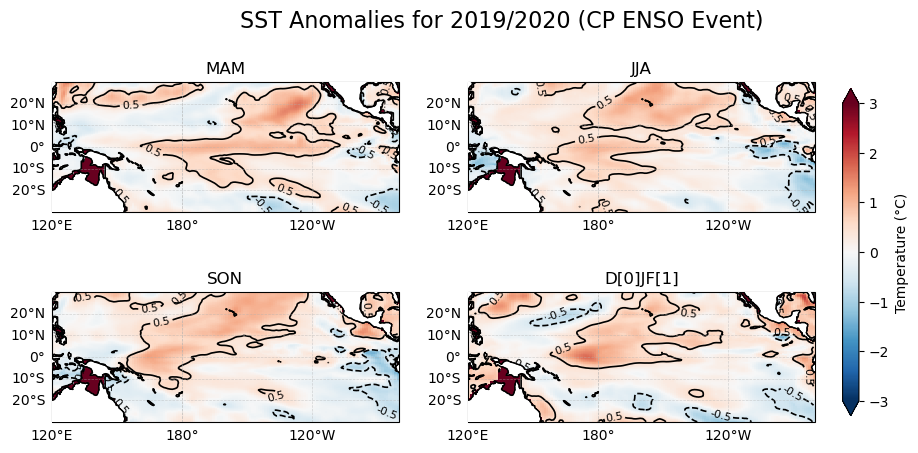

In [257]:
vmin = -3

vmax = 3

fig = plt.figure(figsize=(12, 5))

proj = ccrs.PlateCarree(central_longitude=180)

ax1 = fig.add_subplot(221, projection=proj)
pcm = plot_valuable(ax1, mam, lon, lat, "MAM",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax2 = fig.add_subplot(222, projection=proj)
pcm = plot_valuable(ax2, jja, lon, lat, "JJA",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax3 = fig.add_subplot(223, projection=proj)
pcm = plot_valuable(ax3, son, lon, lat, "SON",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax4 = fig.add_subplot(224, projection=proj)
pcm = plot_valuable(ax4, djf, lon, lat, "D[0]JF[1]",
               vmin=vmin, vmax=vmax, contour_level=0.5)


cbar = fig.colorbar(
    pcm,
    ax=[ax1, ax2, ax3, ax4],
    shrink=0.85,
    pad=0.03,
    extend="both"
)

cbar.set_label("Temperature (°C)")

fig.suptitle(
    f"SST Anomalies for {year}/{year+1} (CP ENSO Event)",
    fontsize=16,
    y=0.98
)

plt.show()

### 3.4 Hovmöller Diagram

In [258]:
def sst_zonal_structure(climate_mean, cp_event):

    zonal_list = []

    for i in range(24):

        if i < 12:
            y = cp_event
            m = i + 1
        else:
            y = cp_event + 1
            m = i - 11

        fn = os.path.join(
            "data",
            f"godas.M.{y}{m:02d}.grb"
        )

        sst, lat, lon = read_sst_godas(fn)

        sst_anom = sst - climate_mean[:, :, m-1]

        sst_anom_sub = sst_anom[
            np.ix_(lat_mask, lon_mask)
        ]

        zonal_mean = np.nanmean(
            sst_anom_sub,
            axis=0
        )

        zonal_list.append(zonal_mean)

    return np.array(zonal_list)

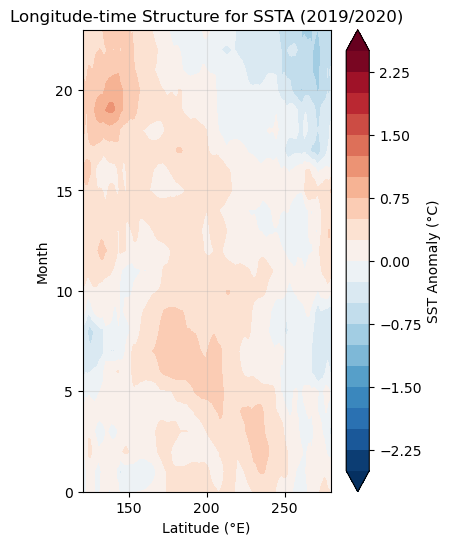

In [267]:
sst_lon_time = sst_zonal_structure(
    sst_cli,
    year
)

plt.figure(figsize=(4, 6))
plt.contourf(
    lon[lon_mask],
    np.arange(24),
    sst_lon_time,
    levels=np.arange(-2.5,2.75,0.25),
    cmap="RdBu_r",
    extend="both"
)
plt.colorbar(label="SST Anomaly (°C)")
plt.title(f"Longitude-time Structure for SSTA ({year}/{year+1})")
plt.ylabel("Month")
plt.xlabel("Latitude (°E)")
plt.grid(alpha=0.3)

In [260]:
# stop here

## Part 4: Composites Analysis

### 4.1 SSTA

In [261]:
cp_enso = [2004, 2009, 2014, 2018, 2019]

mam, jja, son, djf, mam2, jja2, son2 = 0, 0, 0, 0, 0, 0, 0

var = 0 # intermediate variable

for year in cp_enso:

    var, lat, lon = seasonal_mean(sst_cli,
        year,
        [(year, 3), (year, 4), (year, 5)]
    )

    mam += var

    var, _, _ = seasonal_mean(sst_cli,
        year,
        [(year, 6), (year, 7), (year, 8)]
    )

    jja += var

    var, _, _ = seasonal_mean(sst_cli,
        year,
        [(year, 9), (year, 10), (year, 11)]
    )

    son += var

    var, _, _ = seasonal_mean(sst_cli,
        year,
        [(year, 12), (year, 1), (year, 2)]
    )

    djf += var

    var, _, _ = seasonal_mean(sst_cli,
        year+1,
        [(year+1, 3), (year+1, 4), (year+1, 5)]
    )

    mam2 += var

    var, _, _ = seasonal_mean(sst_cli,
        year+1,
        [(year+1, 6), (year+1, 7), (year+1, 8)]
    )

    jja2 += var

    var, _, _ = seasonal_mean(sst_cli,
        year+1,
        [(year+1, 9), (year+1, 10), (year+1, 11)]
    )

    son2 += var

mam /= len(cp_enso)
jja /= len(cp_enso) 
son /= len(cp_enso)
djf /= len(cp_enso) 
mam2 /= len(cp_enso)
jja2 /= len(cp_enso)
son2 /= len(cp_enso)

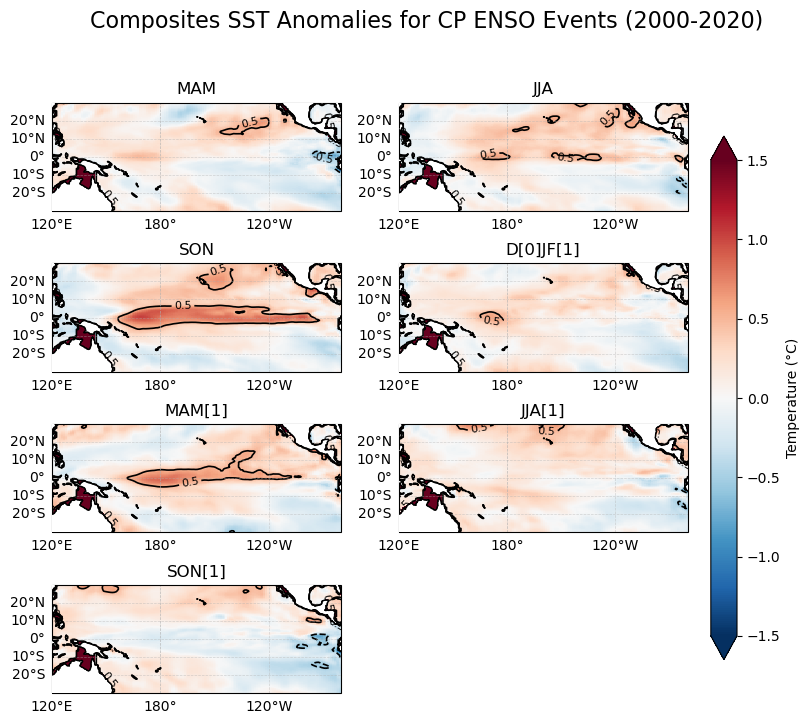

In [262]:
vmin = -1.5

vmax = 1.5

# plot SSTA
fig = plt.figure(figsize=(10, 8))

proj = ccrs.PlateCarree(central_longitude=180)

ax1 = fig.add_subplot(421, projection=proj)
pcm = plot_valuable(ax1, mam, lon, lat, "MAM",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax2 = fig.add_subplot(422, projection=proj)
pcm = plot_valuable(ax2, jja, lon, lat, "JJA",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax3 = fig.add_subplot(423, projection=proj)
pcm = plot_valuable(ax3, son, lon, lat, "SON",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax4 = fig.add_subplot(424, projection=proj)
pcm = plot_valuable(ax4, djf, lon, lat, "D[0]JF[1]",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax5 = fig.add_subplot(425, projection=proj)
pcm = plot_valuable(ax5, mam2, lon, lat, "MAM[1]",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax6 = fig.add_subplot(426, projection=proj)
pcm = plot_valuable(ax6, jja2, lon, lat, "JJA[1]",
               vmin=vmin, vmax=vmax, contour_level=0.5)

ax7 = fig.add_subplot(427, projection=proj)
pcm = plot_valuable(ax7, son2, lon, lat, "SON[1]",
               vmin=vmin, vmax=vmax, contour_level=0.5)

cbar = fig.colorbar(
    pcm,
    ax=[ax1, ax2, ax3, ax4, ax5, ax6, ax7],
    shrink=0.85,
    pad=0.03,
    extend="both"
)

cbar.set_label("Temperature (°C)")

fig.suptitle(
    "Composites SST Anomalies for CP ENSO Events (2000-2020)",
    fontsize=16,
    y=0.98
)

plt.show()

### 4.2 SSHA

In [263]:
def read_ssh_godas(grb_file):
    """
    读取GODAS SSH数据
    返回:
        ssh(lat,lon)
        lat(lat)
        lon(lon)
    """

    inv_file = grb_file + ".inv"
    target_msg = None

    if not os.path.exists(inv_file):
        inv_file = "data\\godas.M.202008.grb.inv"

    with open(inv_file, "r") as f:

        for line in f:

            parts = line.strip().split(":")
            msg_num = int(parts[0])
            var_name = parts[3]
            level_str = parts[4]

            if var_name == "SSHG":
                target_msg = msg_num
                break

    if target_msg is None:
        raise ValueError(f"SSHG not found in {inv_file}")

    grbs = pygrib.open(grb_file)
    g = grbs.message(target_msg)
    ssh = g.values
    lats, lons = g.latlons()

    return ssh, lats[:, 0], lons[0, :]

def seasonal_mean(climate_mean, months, data_dir="data"):

    ssh_list = []

    for y, m in months:
        
        if y == 2003 and m == 3:
            # some data is missing in 03/2002, skip
            continue
        
        fn = os.path.join(
            data_dir,
            f"godas.M.{y}{m:02d}.grb"
        )
        ssh, lat, lon = read_ssh_godas(fn)
        ssh_list.append(ssh-climate_mean[:,:,m-1])

    return np.mean(ssh_list, axis=0), lat, lon

In [264]:
# SSH mean
mean_file = r"D:\desktop_file\cp_enso\data\sshg.mon.ltm.1991-2020.nc"
ds = xr.open_dataset(mean_file)
data = ds['sshg'].values
ssh_cli = data.transpose(1, 2, 0)
print(ssh_cli.shape)

(418, 360, 12)


c:\Users\xueya\miniconda3\envs\deep_learning\lib\site-packages\xarray\coding\times.py:699: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
c:\Users\xueya\miniconda3\envs\deep_learning\lib\site-packages\xarray\core\indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [265]:
# SSHA
mam, jja, son, djf, mam2, jja2, son2 = 0, 0, 0, 0, 0, 0, 0

var = 0 # intermediate variable

for year in cp_enso:

    var, lat, lon = seasonal_mean(ssh_cli,
        [(year, 3), (year, 4), (year, 5)]
    )

    mam += var

    var, _, _ = seasonal_mean(ssh_cli,
        [(year, 6), (year, 7), (year, 8)]
    )

    jja += var

    var, _, _ = seasonal_mean(ssh_cli,
        [(year, 9), (year, 10), (year, 11)]
    )

    son += var

    var, _, _ = seasonal_mean(ssh_cli,
        [(year, 12), (year, 1), (year, 2)]
    )

    djf += var

    var, _, _ = seasonal_mean(ssh_cli,
        [(year+1, 3), (year+1, 4), (year+1, 5)]
    )

    mam2 += var

    var, _, _ = seasonal_mean(ssh_cli,
        [(year+1, 6), (year+1, 7), (year+1, 8)]
    )

    jja2 += var

    var, _, _ = seasonal_mean(ssh_cli,
        [(year+1, 9), (year+1, 10), (year+1, 11)]
    )

    son2 += var

mam /= len(cp_enso)
jja /= len(cp_enso) 
son /= len(cp_enso)
djf /= len(cp_enso) 
mam2 /= len(cp_enso)
jja2 /= len(cp_enso)
son2 /= len(cp_enso)

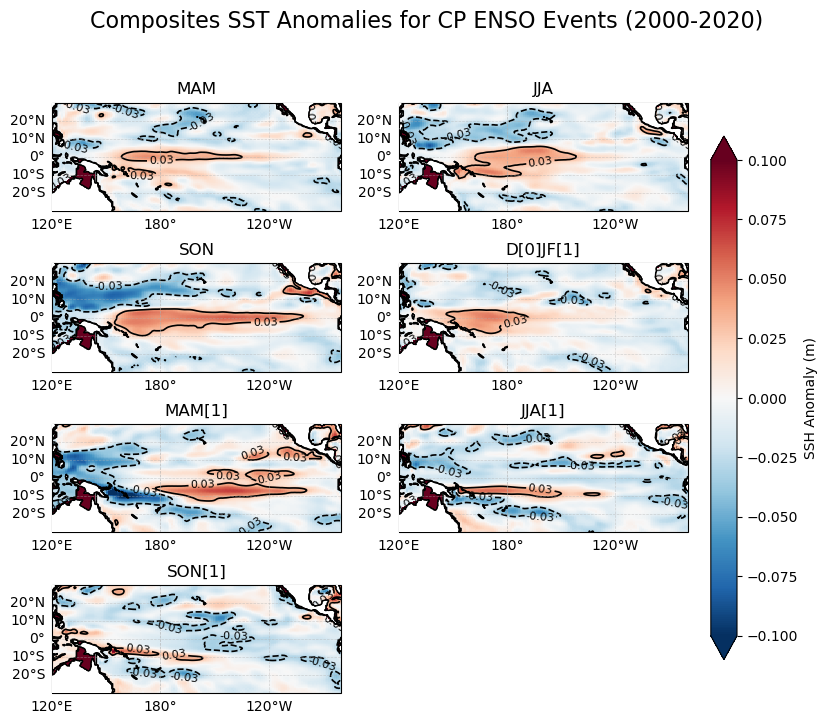

In [266]:
vmin = -0.1

vmax = 0.1

# plot SSTA
fig = plt.figure(figsize=(10, 8))

proj = ccrs.PlateCarree(central_longitude=180)

ax1 = fig.add_subplot(421, projection=proj)
pcm = plot_valuable(ax1, mam, lon, lat, "MAM",
               vmin=vmin, vmax=vmax, contour_level=0.03)

ax2 = fig.add_subplot(422, projection=proj)
pcm = plot_valuable(ax2, jja, lon, lat, "JJA",
               vmin=vmin, vmax=vmax, contour_level=0.03)

ax3 = fig.add_subplot(423, projection=proj)
pcm = plot_valuable(ax3, son, lon, lat, "SON",
               vmin=vmin, vmax=vmax, contour_level=0.03)

ax4 = fig.add_subplot(424, projection=proj)
pcm = plot_valuable(ax4, djf, lon, lat, "D[0]JF[1]",
               vmin=vmin, vmax=vmax, contour_level=0.03)

ax5 = fig.add_subplot(425, projection=proj)
pcm = plot_valuable(ax5, mam2, lon, lat, "MAM[1]",
               vmin=vmin, vmax=vmax, contour_level=0.03)

ax6 = fig.add_subplot(426, projection=proj)
pcm = plot_valuable(ax6, jja2, lon, lat, "JJA[1]",
               vmin=vmin, vmax=vmax, contour_level=0.03)

ax7 = fig.add_subplot(427, projection=proj)
pcm = plot_valuable(ax7, son2, lon, lat, "SON[1]",
               vmin=vmin, vmax=vmax, contour_level=0.03)

cbar = fig.colorbar(
    pcm,
    ax=[ax1, ax2, ax3, ax4, ax5, ax6, ax7],
    shrink=0.85,
    pad=0.03,
    extend="both"
)

cbar.set_label("SSH Anomaly (m)")

fig.suptitle(
    "Composites SST Anomalies for CP ENSO Events (2000-2020)",
    fontsize=16,
    y=0.98
)

plt.show()